# Area C Hourly Access Analysis

This notebook evaluates Area C hourly access volume as an exposure proxy for crash analysis in central Milan.

Figures are displayed inline only; no figures are saved to disk.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.options.display.max_columns = 200
pd.options.display.float_format = "{:.4f}".format

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
project_root = next(root for root in candidate_roots if (root / "data").exists())
processed_dir = project_root / "data" / "processed"

long_path = processed_dir / "area_c_hourly_vehicle_category.csv"
wide_path = processed_dir / "area_c_hourly_wide.csv"
monthly_path = processed_dir / "area_c_monthly_exposure.csv"
ring_exposure_path = processed_dir / "milan_crashes_city_ring_area_c_exposure.csv"

area_c_long = pd.read_csv(long_path, parse_dates=["date"])
area_c_wide = pd.read_csv(wide_path, parse_dates=["date"])
area_c_monthly = pd.read_csv(monthly_path, parse_dates=["month_start", "month_end"])
ring_exposure = pd.read_csv(ring_exposure_path, parse_dates=["month_start"])

print(f"Project root: {project_root}")


Project root: /Users/faustozamparelli/Developer/MilanCrash


## Load and Inspect Processed Area C Data


In [2]:
print("Long shape:", area_c_long.shape)
print("Wide shape:", area_c_wide.shape)
print("Monthly shape:", area_c_monthly.shape)
print("Date range:", area_c_wide["date"].min().date(), "to", area_c_wide["date"].max().date())
print("Years:", sorted(area_c_wide["year"].dropna().astype(int).unique()))
print("Vehicle categories:", sorted(area_c_long["vehicle_category"].dropna().unique()))
print("Missing values, long:")
print(area_c_long.isna().sum())
print("Missing values, wide:")
print(area_c_wide.isna().sum())
print("Wide summaries:")
display(area_c_wide.describe(include="all"))


Long shape: (193845, 12)
Wide shape: (39109, 14)
Monthly shape: (153, 19)
Date range: 2012-01-01 to 2016-09-18
Years: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
Vehicle categories: ['altro', 'bus', 'merci', 'nc', 'persone']
Missing values, long:
date                0
year                0
month               0
day                 0
weekday             0
weekday_name        0
is_weekend          0
hour                0
time_band           0
vehicle_category    0
accesses            0
areac               0
dtype: int64
Missing values, wide:
date                0
hour                0
total_accesses      0
accesses_persone    0
accesses_merci      0
accesses_bus        0
accesses_altro      0
accesses_nc         0
areac               0
year                0
month               0
weekday             0
is_weekend          0
time_band           0
dtype: int64
Wide summaries:


,date,hour,total_accesses,accesses_persone,accesses_merci,accesses_bus,accesses_altro,accesses_nc,areac,year,month,weekday,is_weekend,time_band
count,39109,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109.0000,39109,39109
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,night
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27974,9791
mean,2014-04-14 15:30:57.669590,11.4942,4854.0471,3811.2464,402.9456,67.2510,52.4418,520.1622,0.3273,2013.8148,6.1710,2.9962,NaN,NaN
min,2012-01-01 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2012.0000,1.0000,0.0000,NaN,NaN
25%,2013-02-13 00:00:00,5.0000,1807.0000,1414.0000,68.0000,25.0000,13.0000,153.0000,0.0000,2013.0000,3.0000,1.0000,NaN,NaN
50%,2014-03-28 00:00:00,11.0000,4662.0000,3848.0000,159.0000,57.0000,25.0000,360.0000,0.0000,2014.0000,6.0000,3.0000,NaN,NaN
75%,2015-05-25 00:00:00,17.0000,7601.0000,5809.0000,687.0000,102.0000,75.0000,791.0000,1.0000,2015.0000,9.0000,5.0000,NaN,NaN
max,2016-09-18 00:00:00,23.0000,13393.0000,12484.0000,1902.0000,430.0000,337.0000,3705.0000,1.0000,2016.0000,12.0000,6.0000,NaN,NaN


## Quality and Relevance Check

This checks whether the dataset is useful enough to merge into the crash analysis. The key checks are year coverage, completeness after cleaning, category consistency, and alignment with central Milan ring geography.


In [3]:
quality = {
    "hourly_category_years": sorted(area_c_wide["year"].dropna().astype(int).unique().tolist()),
    "hourly_category_date_start": area_c_wide["date"].min().date(),
    "hourly_category_date_end": area_c_wide["date"].max().date(),
    "monthly_exposure_years": sorted(area_c_monthly["year"].dropna().astype(int).unique().tolist()),
    "monthly_exposure_start": area_c_monthly["month_start"].min().date(),
    "monthly_exposure_end": area_c_monthly["month_start"].max().date(),
    "hourly_rows": len(area_c_wide),
    "long_rows": len(area_c_long),
    "monthly_rows": len(area_c_monthly),
    "vehicle_categories": sorted(area_c_long["vehicle_category"].dropna().unique().tolist()),
    "missing_cells_long": int(area_c_long.isna().sum().sum()),
    "missing_cells_wide": int(area_c_wide.isna().sum().sum()),
}
print(quality)

coverage_cols = [
    col for col in [
        "year", "month", "days_observed", "source_days_hourly_category",
        "source_days_daily_total", "total_accesses", "mean_daily_accesses",
    ]
    if col in area_c_monthly.columns
]
coverage_by_month = area_c_monthly[coverage_cols]
print("Coverage by month")
display(coverage_by_month)

print("Decision: high-quality enough for central-ring monthly exposure from 2012 through available 2024, with vehicle-category composition only where hourly category data exists. It is not suitable as an all-Milan denominator.")


{'hourly_category_years': [2012, 2013, 2014, 2015, 2016], 'hourly_category_date_start': datetime.date(2012, 1, 1), 'hourly_category_date_end': datetime.date(2016, 9, 18), 'monthly_exposure_years': [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 'monthly_exposure_start': datetime.date(2012, 1, 1), 'monthly_exposure_end': datetime.date(2024, 11, 1), 'hourly_rows': 39109, 'long_rows': 193845, 'monthly_rows': 153, 'vehicle_categories': ['altro', 'bus', 'merci', 'nc', 'persone'], 'missing_cells_long': 0, 'missing_cells_wide': 0}
Coverage by month


,year,month,days_observed,source_days_hourly_category,source_days_daily_total,total_accesses,mean_daily_accesses
0,2012,1,31,31,0,4053264.0000,130750.4516
1,2012,2,29,29,0,3885254.0000,133974.2759
2,2012,3,30,30,0,4137599.0000,137919.9667
3,2012,4,29,29,0,3633084.0000,125278.7586
4,2012,5,31,31,0,4289819.0000,138381.2581
...,...,...,...,...,...,...,...
148,2024,7,31,0,31,3475109.0000,112100.2903
149,2024,8,1,0,1,81864.0000,81864.0000
150,2024,9,30,0,30,4000445.0000,133348.1667
151,2024,10,31,0,31,4016358.0000,129559.9355


Decision: high-quality enough for central-ring monthly exposure from 2012 through available 2024, with vehicle-category composition only where hourly category data exists. It is not suitable as an all-Milan denominator.


## Exploratory Analysis


Total accesses by hour


,total_accesses
hour,
0,4968678.0000
1,2846767.0000
2,1655845.0000
3,1179488.0000
4,1216938.0000
5,2067270.0000
6,4710797.0000
7,8738845.0000
8,10212466.0000


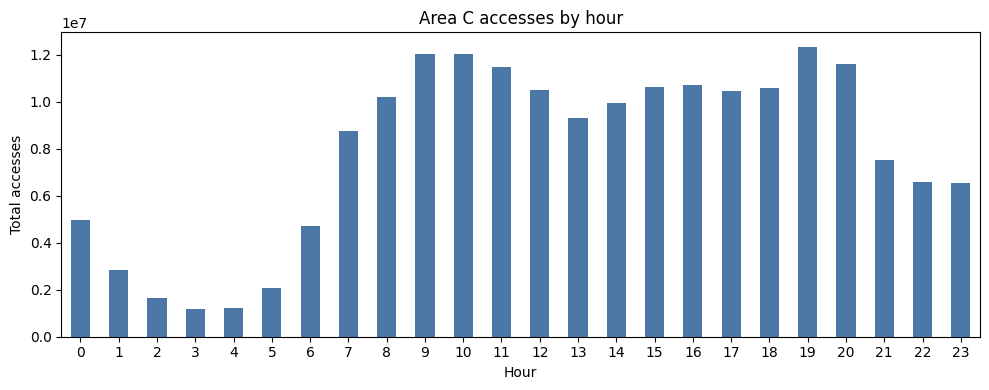

Total accesses by weekday, Monday=0


,total_accesses
weekday,
0,26169631.0000
1,27883745.0000
2,28539968.0000
3,29039864.0000
4,28670750.0000
5,27671963.0000
6,21861008.0000


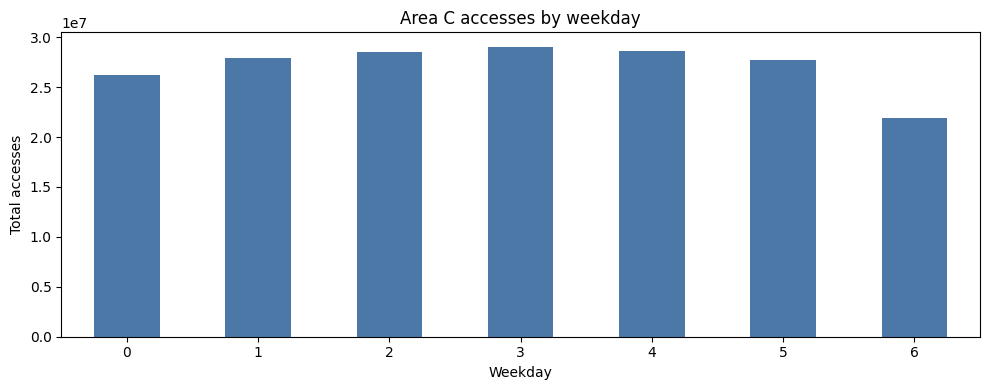

Total accesses by month


,total_accesses
month,
1,16843514.0000
2,16772333.0000
3,18381223.0000
4,17105773.0000
5,18430712.0000
6,16817472.0000
7,15954120.0000
8,8934244.0000
9,16960502.0000


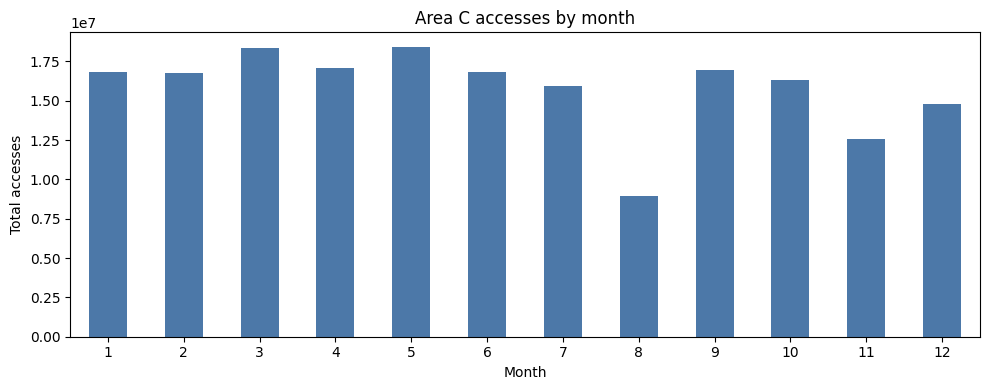

Hour x weekday table


weekday,0,1,2,3,4,5,6
hour,,,,,,,
0,494770.0000,472601.0000,600820.0000,668062.0000,731155.0000,934485.0000,1066785.0000
1,249703.0000,236658.0000,303993.0000,342225.0000,393286.0000,597977.0000,722925.0000
2,132268.0000,126568.0000,161348.0000,189681.0000,217941.0000,377089.0000,450950.0000
3,99607.0000,96010.0000,119662.0000,139217.0000,159171.0000,278469.0000,287352.0000
4,135609.0000,133500.0000,141425.0000,156769.0000,175840.0000,249414.0000,224381.0000
5,313110.0000,305307.0000,294859.0000,313864.0000,322107.0000,300668.0000,217355.0000
6,796410.0000,809075.0000,793593.0000,795436.0000,774484.0000,461558.0000,280241.0000
7,1512515.0000,1563290.0000,1550126.0000,1522236.0000,1500899.0000,768017.0000,321762.0000
8,1697332.0000,1774553.0000,1756388.0000,1730078.0000,1730426.0000,1044091.0000,479598.0000


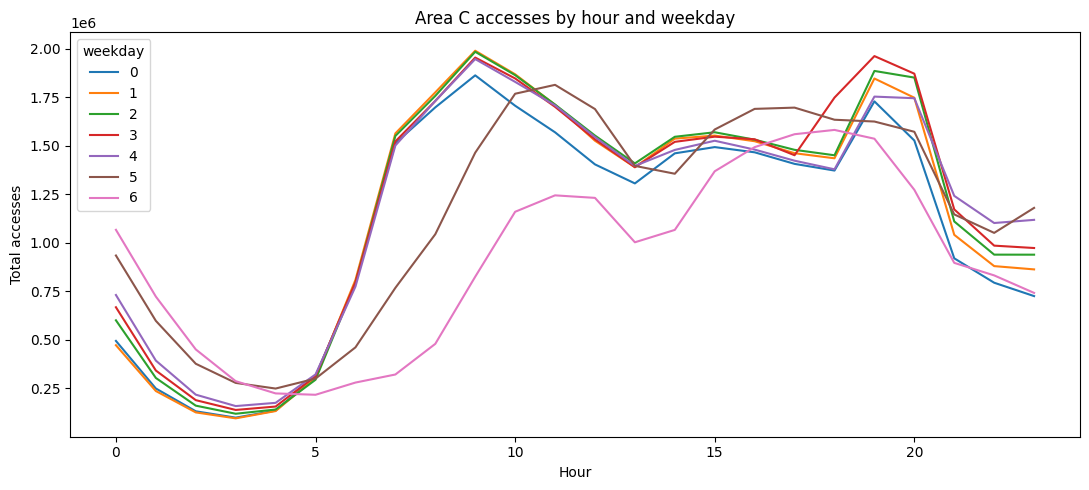

Total accesses by time band


,total_accesses
time_band,
night,13934986.0000
morning_peak,35685819.0000
midday,63860936.0000
evening_peak,44121202.0000
evening,32233986.0000


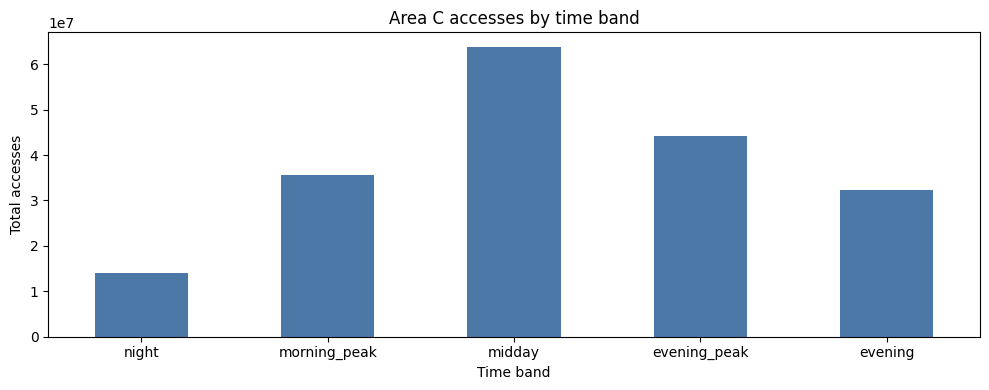

Accesses by vehicle category


,accesses
vehicle_category,
persone,149054036.0000
nc,20343024.0000
merci,15758800.0000
bus,2630121.0000
altro,2050948.0000


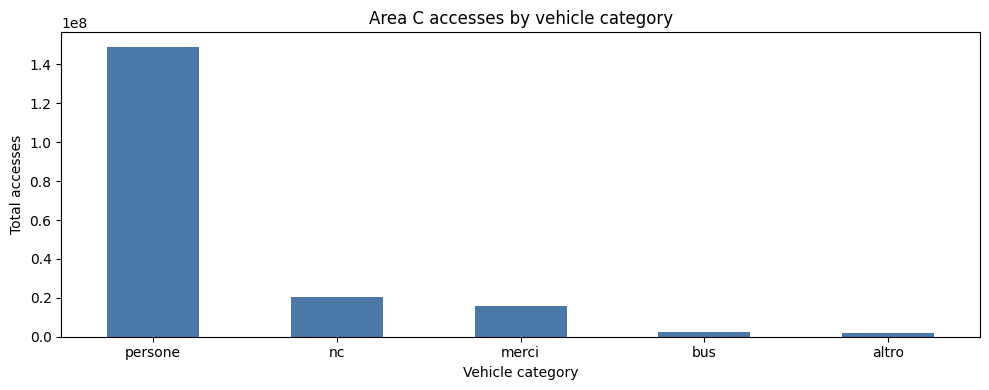

Accesses by hour and vehicle category


vehicle_category,altro,bus,merci,nc,persone
hour,,,,,
0,15550.0000,56405.0000,87038.0000,546080.0000,4263605.0000
1,15337.0000,31644.0000,72065.0000,353214.0000,2374507.0000
2,14072.0000,14473.0000,65911.0000,243656.0000,1317733.0000
3,16986.0000,13771.0000,76115.0000,195761.0000,876855.0000
4,22346.0000,14372.0000,141595.0000,186964.0000,851661.0000
5,69447.0000,35025.0000,321464.0000,241542.0000,1399792.0000
6,164066.0000,99235.0000,925106.0000,422516.0000,3099874.0000
7,221598.0000,175394.0000,1689605.0000,783266.0000,5868982.0000
8,179046.0000,179922.0000,1476241.0000,1131442.0000,7245815.0000


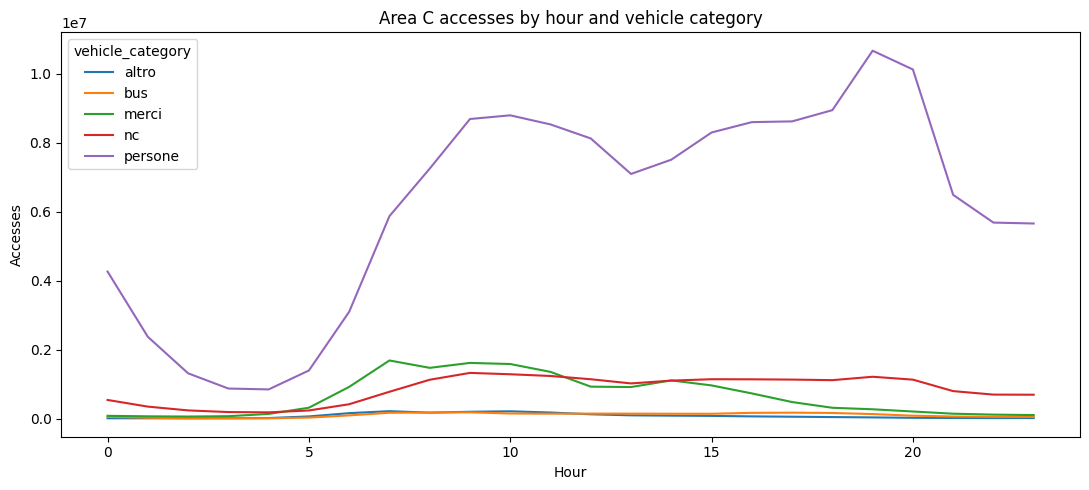

Area C active/inactive comparison


,count,sum,mean,median
areac,,,,
0,26309,100089732.0000,3804.3913,3305.0000
1,12800,89747197.0000,7011.4998,7512.5000


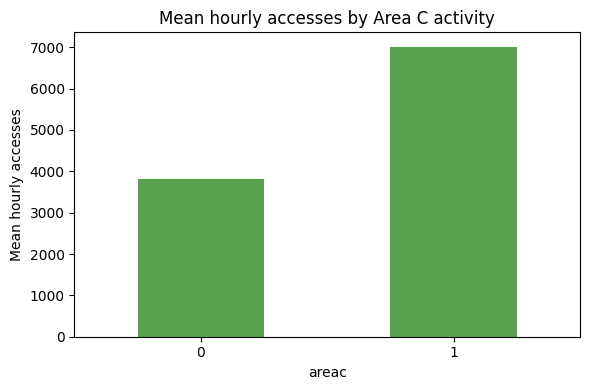

In [4]:
def bar_plot(series, title, xlabel, ylabel="Total accesses"):
    ax = series.plot(kind="bar", figsize=(10, 4), color="#4c78a8")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

hour_totals = area_c_wide.groupby("hour")["total_accesses"].sum()
weekday_totals = area_c_wide.groupby("weekday")["total_accesses"].sum()
month_totals = area_c_wide.groupby("month")["total_accesses"].sum()
time_band_totals = area_c_wide.groupby("time_band")["total_accesses"].sum().reindex(["night", "morning_peak", "midday", "evening_peak", "evening"])
category_totals = area_c_long.groupby("vehicle_category")["accesses"].sum().sort_values(ascending=False)
hour_weekday = area_c_wide.pivot_table(index="hour", columns="weekday", values="total_accesses", aggfunc="sum", fill_value=0)
hour_category = area_c_long.pivot_table(index="hour", columns="vehicle_category", values="accesses", aggfunc="sum", fill_value=0)

print("Total accesses by hour")
display(hour_totals.to_frame("total_accesses"))
bar_plot(hour_totals, "Area C accesses by hour", "Hour")

print("Total accesses by weekday, Monday=0")
display(weekday_totals.to_frame("total_accesses"))
bar_plot(weekday_totals, "Area C accesses by weekday", "Weekday")

print("Total accesses by month")
display(month_totals.to_frame("total_accesses"))
bar_plot(month_totals, "Area C accesses by month", "Month")

print("Hour x weekday table")
display(hour_weekday)
ax = hour_weekday.plot(figsize=(11, 5))
ax.set_title("Area C accesses by hour and weekday")
ax.set_xlabel("Hour")
ax.set_ylabel("Total accesses")
plt.tight_layout()
plt.show()

print("Total accesses by time band")
display(time_band_totals.to_frame("total_accesses"))
bar_plot(time_band_totals, "Area C accesses by time band", "Time band")

print("Accesses by vehicle category")
display(category_totals.to_frame("accesses"))
bar_plot(category_totals, "Area C accesses by vehicle category", "Vehicle category")

print("Accesses by hour and vehicle category")
display(hour_category)
ax = hour_category.plot(figsize=(11, 5))
ax.set_title("Area C accesses by hour and vehicle category")
ax.set_xlabel("Hour")
ax.set_ylabel("Accesses")
plt.tight_layout()
plt.show()

if "areac" in area_c_wide.columns and area_c_wide["areac"].notna().any():
    areac_summary = area_c_wide.groupby("areac")["total_accesses"].agg(["count", "sum", "mean", "median"])
    print("Area C active/inactive comparison")
    display(areac_summary)
    ax = areac_summary["mean"].plot(kind="bar", figsize=(6, 4), color="#59a14f")
    ax.set_title("Mean hourly accesses by Area C activity")
    ax.set_xlabel("areac")
    ax.set_ylabel("Mean hourly accesses")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## Statistical Analysis A: Weekday/Weekend by Time Band


In [5]:
time_band_order = ["night", "morning_peak", "midday", "evening_peak", "evening"]
contingency = (
    area_c_wide
    .pivot_table(index="is_weekend", columns="time_band", values="total_accesses", aggfunc="sum", fill_value=0)
    .reindex(columns=time_band_order)
)
print("Contingency table: total accesses by weekend flag and time band")
display(contingency)

try:
    from scipy.stats import chi2_contingency
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"p-value: {p_value:.6g}")
    if p_value < 0.05:
        print("Interpretation: weekday and weekend accesses are distributed differently across time bands.")
    else:
        print("Interpretation: no statistically clear difference in time-band distribution was detected.")
except ImportError:
    print("Install scipy to run the chi-square test: uv add scipy")


Contingency table: total accesses by weekend flag and time band


time_band,night,morning_peak,midday,evening_peak,evening
is_weekend,,,,,
False,8227136.0000,30041346.0000,47184414.0000,31308864.0000,23542198.0000
True,5707850.0000,5644473.0000,16676522.0000,12812338.0000,8691788.0000


Chi-square statistic: 3762591.0820
Degrees of freedom: 4
p-value: 0
Interpretation: weekday and weekend accesses are distributed differently across time bands.


## Statistical Analysis B: Hourly Access Count Model


In [6]:
model_cols = ["date", "hour", "weekday", "month", "is_weekend", "time_band", "total_accesses"]
if "areac" in area_c_wide.columns:
    model_cols.append("areac")

model_table = area_c_wide[model_cols].copy()
model_path = processed_dir / "area_c_hourly_model_table.csv"
model_table.to_csv(model_path, index=False)
print(f"Saved {model_path.relative_to(project_root)} rows={len(model_table):,}")
display(model_table.head())

try:
    import statsmodels.formula.api as smf
    formula = "total_accesses ~ C(hour) + C(weekday) + C(month)"
    if "areac" in model_table.columns and model_table["areac"].notna().any():
        formula += " + areac"
    model_data = model_table.dropna(subset=["total_accesses", "hour", "weekday", "month"]).copy()
    fit = smf.ols(formula, data=model_data).fit(cov_type="HC3")
    print(fit.summary())
except ImportError:
    print("Install statsmodels to run the model: uv add statsmodels")


Saved data/processed/area_c_hourly_model_table.csv rows=39,109


,date,hour,weekday,month,is_weekend,time_band,total_accesses,areac
0,2012-01-01,0,6,1,True,night,2738.0000,0
1,2012-01-01,1,6,1,True,night,4832.0000,0
2,2012-01-01,2,6,1,True,night,4348.0000,0
3,2012-01-01,3,6,1,True,night,3113.0000,0
4,2012-01-01,4,6,1,True,night,2195.0000,0


                            OLS Regression Results                            
Dep. Variable:         total_accesses   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     3508.
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:34:59   Log-Likelihood:            -3.4926e+05
No. Observations:               39109   AIC:                         6.986e+05
Df Residuals:                   39067   BIC:                         6.990e+05
Df Model:                          41                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        3249.4952     50.227     

## Statistical Analysis C: Vehicle Composition


In [7]:
category_cols = [col for col in area_c_wide.columns if col.startswith("accesses_")]
composition = area_c_wide[["date", "hour", "total_accesses"] + category_cols].copy()
for col in category_cols:
    suffix = col.replace("accesses_", "")
    composition[f"share_{suffix}"] = composition[col] / composition["total_accesses"].where(composition["total_accesses"] != 0)

composition_path = processed_dir / "area_c_vehicle_composition.csv"
composition.to_csv(composition_path, index=False)
print(f"Saved {composition_path.relative_to(project_root)} rows={len(composition):,}")
display(composition.head())


Saved data/processed/area_c_vehicle_composition.csv rows=39,109


,date,hour,total_accesses,accesses_persone,accesses_merci,accesses_bus,accesses_altro,accesses_nc,share_persone,share_merci,share_bus,share_altro,share_nc
0,2012-01-01,0,2738.0000,2572.0000,59.0000,37.0000,16.0000,54.0000,0.9394,0.0215,0.0135,0.0058,0.0197
1,2012-01-01,1,4832.0000,4608.0000,85.0000,39.0000,25.0000,75.0000,0.9536,0.0176,0.0081,0.0052,0.0155
2,2012-01-01,2,4348.0000,4158.0000,77.0000,36.0000,16.0000,61.0000,0.9563,0.0177,0.0083,0.0037,0.0140
3,2012-01-01,3,3113.0000,2939.0000,72.0000,31.0000,22.0000,49.0000,0.9441,0.0231,0.0100,0.0071,0.0157
4,2012-01-01,4,2195.0000,2073.0000,56.0000,35.0000,6.0000,25.0000,0.9444,0.0255,0.0159,0.0027,0.0114


## Integration-Ready Exposure Output


In [8]:
share_cols = [col for col in composition.columns if col.startswith("share_")]
merge_ready = (
    area_c_wide
    .merge(composition[["date", "hour"] + share_cols], on=["date", "hour"], how="left")
    .sort_values(["date", "hour"])
    .reset_index(drop=True)
)

preferred_order = [
    "date", "hour", "total_accesses",
    *[col for col in category_cols if col in merge_ready.columns],
    *share_cols,
    "areac", "weekday", "month", "is_weekend", "time_band",
]
merge_ready = merge_ready[[col for col in preferred_order if col in merge_ready.columns]]
merge_path = processed_dir / "area_c_exposure_for_crash_merge.csv"
merge_ready.to_csv(merge_path, index=False)
print(f"Saved {merge_path.relative_to(project_root)} rows={len(merge_ready):,}")
display(merge_ready.head())


Saved data/processed/area_c_exposure_for_crash_merge.csv rows=39,109


,date,hour,total_accesses,accesses_persone,accesses_merci,accesses_bus,accesses_altro,accesses_nc,share_persone,share_merci,share_bus,share_altro,share_nc,areac,weekday,month,is_weekend,time_band
0,2012-01-01,0,2738.0000,2572.0000,59.0000,37.0000,16.0000,54.0000,0.9394,0.0215,0.0135,0.0058,0.0197,0,6,1,True,night
1,2012-01-01,1,4832.0000,4608.0000,85.0000,39.0000,25.0000,75.0000,0.9536,0.0176,0.0081,0.0052,0.0155,0,6,1,True,night
2,2012-01-01,2,4348.0000,4158.0000,77.0000,36.0000,16.0000,61.0000,0.9563,0.0177,0.0083,0.0037,0.0140,0,6,1,True,night
3,2012-01-01,3,3113.0000,2939.0000,72.0000,31.0000,22.0000,49.0000,0.9441,0.0231,0.0100,0.0071,0.0157,0,6,1,True,night
4,2012-01-01,4,2195.0000,2073.0000,56.0000,35.0000,6.0000,25.0000,0.9444,0.0255,0.0159,0.0027,0.0114,0,6,1,True,night


## Central-Ring Crash Exposure Merge

This is the analysis gain: for the rings inside the Mura Spagnole, monthly crash counts can now be read alongside Area C traffic entering that central zone.


Central ring rows with Area C exposure: (306, 26)


,Anno,Mese,Cerchia,Incidenti,Feriti,Morti,total_accesses,incidents_per_100k_area_c_accesses,injuries_per_100k_area_c_accesses,deaths_per_100k_area_c_accesses
660,2012,1,Dalla Cerchia dei Navigli alle Mura Spagnole,68,83,0,4053264.0000,1.6777,2.0477,0.0000
663,2012,1,Entro la Cerchia dei Navigli,31,35,0,4053264.0000,0.7648,0.8635,0.0000
665,2012,2,Dalla Cerchia dei Navigli alle Mura Spagnole,36,41,0,3885254.0000,0.9266,1.0553,0.0000
668,2012,2,Entro la Cerchia dei Navigli,19,23,0,3885254.0000,0.4890,0.5920,0.0000
670,2012,3,Dalla Cerchia dei Navigli alle Mura Spagnole,67,80,0,4137599.0000,1.6193,1.9335,0.0000


Central-ring monthly crash rate summary


,incidents_per_100k_area_c_accesses
count,153.0000
mean,1.9126
std,2.9908
min,0.2982
25%,1.2646
50%,1.4279
75%,1.7426
max,36.6461


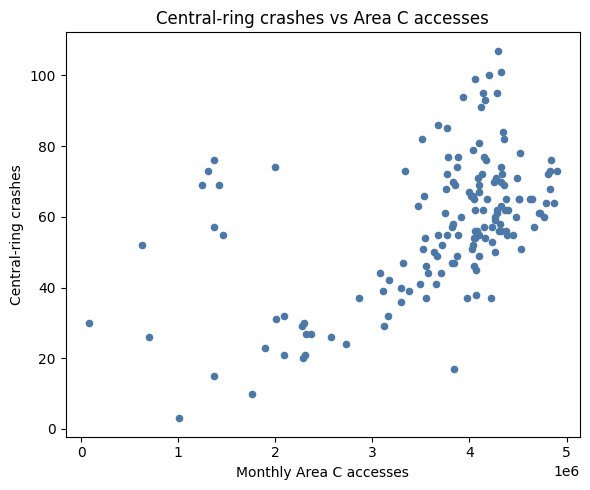

In [9]:
central = ring_exposure[ring_exposure["inside_mura_spagnole"] & ring_exposure["total_accesses"].notna()].copy()
print("Central ring rows with Area C exposure:", central.shape)
display(central[[
    "Anno", "Mese", "Cerchia", "Incidenti", "Feriti", "Morti", "total_accesses",
    "incidents_per_100k_area_c_accesses", "injuries_per_100k_area_c_accesses", "deaths_per_100k_area_c_accesses",
]].head())

monthly_central = (
    central.groupby(["Anno", "Mese"], as_index=False)
    .agg(Incidenti=("Incidenti", "sum"), Feriti=("Feriti", "sum"), Morti=("Morti", "sum"), total_accesses=("total_accesses", "first"))
)
monthly_central["incidents_per_100k_area_c_accesses"] = monthly_central["Incidenti"] / monthly_central["total_accesses"] * 100_000
print("Central-ring monthly crash rate summary")
display(monthly_central[["incidents_per_100k_area_c_accesses"]].describe())

ax = monthly_central.plot(
    x="total_accesses", y="Incidenti", kind="scatter", figsize=(6, 5), color="#4c78a8"
)
ax.set_title("Central-ring crashes vs Area C accesses")
ax.set_xlabel("Monthly Area C accesses")
ax.set_ylabel("Central-ring crashes")
plt.tight_layout()
plt.show()
